# 선문대학교 컴퓨터공학부
# 2022243101 최완우

### 3.3.2.시각화_프로젝트_대중교통_데이터_시각화하기

In [1]:
import pandas as pd

subwayfee_df = pd.read_csv('3.3.2.subwayfee.csv')

subwayfee_df.head()

,사용월,호선명,역ID,지하철역,유임승차,유임하차,무임승차,무임하차
0,2026-02,1호선,150,서울역,1760286,1671967,226741,214630
1,2026-02,1호선,151,시청,574229,584626,91962,90776
2,2026-02,1호선,152,종각,868096,844844,133930,125034
3,2026-02,1호선,153,종로3가,416372,375520,255623,233394
4,2026-02,1호선,154,종로5가,406958,396368,208550,202601


In [2]:
subwayfee_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 621 entries, 0 to 620
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   사용월     621 non-null    str  
 1   호선명     621 non-null    str  
 2   역ID     621 non-null    int64
 3   지하철역    621 non-null    str  
 4   유임승차    621 non-null    int64
 5   유임하차    621 non-null    int64
 6   무임승차    621 non-null    int64
 7   무임하차    621 non-null    int64
dtypes: int64(5), str(3)
memory usage: 38.9 KB


In [3]:
subwayfee_df['rate'] = subwayfee_df['유임승차'] / subwayfee_df['무임승차']

subwayfee_df.head()

,사용월,호선명,역ID,지하철역,유임승차,유임하차,무임승차,무임하차,rate
0,2026-02,1호선,150,서울역,1760286,1671967,226741,214630,7.763422
1,2026-02,1호선,151,시청,574229,584626,91962,90776,6.244199
2,2026-02,1호선,152,종각,868096,844844,133930,125034,6.481714
3,2026-02,1호선,153,종로3가,416372,375520,255623,233394,1.628852
4,2026-02,1호선,154,종로5가,406958,396368,208550,202601,1.951369


In [4]:
subwayfee_df['rate'] = subwayfee_df['rate'].round(2)

subwayfee_df.head()

,사용월,호선명,역ID,지하철역,유임승차,유임하차,무임승차,무임하차,rate
0,2026-02,1호선,150,서울역,1760286,1671967,226741,214630,7.76
1,2026-02,1호선,151,시청,574229,584626,91962,90776,6.24
2,2026-02,1호선,152,종각,868096,844844,133930,125034,6.48
3,2026-02,1호선,153,종로3가,416372,375520,255623,233394,1.63
4,2026-02,1호선,154,종로5가,406958,396368,208550,202601,1.95


In [5]:
subwayfee_df[subwayfee_df['rate'] == subwayfee_df['rate'].max()]

,사용월,호선명,역ID,지하철역,유임승차,유임하차,무임승차,무임하차,rate
269,2026-02,일산선,1949,지축,25,0,0,0,inf
334,2026-02,경의선,1296,계양,1,0,0,0,inf
335,2026-02,경의선,1297,검암,2,0,0,0,inf
525,2026-02,7호선,2753,까치울,1,0,0,0,inf


In [6]:
subwayfee_df = pd.read_csv('3.3.2.subwayfee.csv')

subwayfee_df.loc[subwayfee_df['무임승차'] != 0, 'rate'] = subwayfee_df['유임승차'] / subwayfee_df['무임승차']

subwayfee_df['rate'] = subwayfee_df['rate'].round(2)

subwayfee_df.head()

,사용월,호선명,역ID,지하철역,유임승차,유임하차,무임승차,무임하차,rate
0,2026-02,1호선,150,서울역,1760286,1671967,226741,214630,7.76
1,2026-02,1호선,151,시청,574229,584626,91962,90776,6.24
2,2026-02,1호선,152,종각,868096,844844,133930,125034,6.48
3,2026-02,1호선,153,종로3가,416372,375520,255623,233394,1.63
4,2026-02,1호선,154,종로5가,406958,396368,208550,202601,1.95


In [7]:
subwayfee_df[subwayfee_df['rate'] == subwayfee_df['rate'].max()]

,사용월,호선명,역ID,지하철역,유임승차,유임하차,무임승차,무임하차,rate
72,2026-02,3호선,321,충무로,132,0,2,0,66.0


In [8]:
# 데이터 다시 불러오기
subwayfee_df = pd.read_csv('3.3.2.subwayfee.csv')

# 분모인 '유임승차'+'무임승차'가 0이 아닌 경우에만 백분율로 계산
subwayfee_df.loc[subwayfee_df['무임승차'] != 0, 'rate'] = subwayfee_df['유임승차'] / (subwayfee_df['유임승차'] + subwayfee_df['무임승차'])

# rate을 반올림하여 다시 저장하기
subwayfee_df['rate'] = subwayfee_df['rate'].round(2)

result = subwayfee_df[(subwayfee_df['유임승차'] + subwayfee_df['무임승차']) > 10000].sort_values(by = 'rate', ascending = False)

result.head(10)

,사용월,호선명,역ID,지하철역,유임승차,유임하차,무임승차,무임하차,rate
572,2026-02,공항철도 1호선,4203,홍대입구,452568,418472,19761,18244,0.96
120,2026-02,경부선,1001,서울역,308230,108864,16126,4226,0.95
48,2026-02,2호선,239,홍대입구,1928113,2076081,92028,89560,0.95
465,2026-02,6호선,2632,한강진,222458,269358,15185,15568,0.94
18,2026-02,2호선,209,한양대,193841,210702,13018,13745,0.94
574,2026-02,공항철도 1호선,4206,마곡나루(서울식물원),332620,322452,22453,22680,0.94
20,2026-02,2호선,211,성수,1339476,1435625,90316,90657,0.94
559,2026-02,9호선,4115,여의도,683949,657863,52568,48322,0.93
47,2026-02,2호선,238,합정,772733,845529,60855,61753,0.93
569,2026-02,9호선,4125,신논현,770695,795832,54126,52678,0.93


In [9]:
result['rate'] = result['rate'] * 100

result[result['rate'] == result['rate'].max()][['지하철역', '호선명', 'rate']]

,지하철역,호선명,rate
572,홍대입구,공항철도 1호선,96.0


In [10]:
import pandas as pd

subwayfee_df = pd.read_csv('3.3.2.subwayfee.csv')

In [11]:
subwayfee_df[subwayfee_df['유임승차'] == subwayfee_df['유임승차'].max()][['지하철역', '호선명', '유임승차']]

,지하철역,호선명,유임승차
25,잠실(송파구청),2호선,1931871


In [12]:
subwayfee_df[subwayfee_df['유임하차'] == subwayfee_df['유임하차'].max()][['지하철역', '호선명', '유임하차']]

,지하철역,호선명,유임하차
48,홍대입구,2호선,2076081


In [13]:
# 무임 승차 인원이 많은 곳
subwayfee_df[subwayfee_df['무임승차'] == subwayfee_df['무임승차'].max()][['지하철역', '호선명', '무임승차']]

,지하철역,호선명,무임승차
125,영등포,경부선,286362


In [14]:
# 무임 하차 인원이 많은 곳
subwayfee_df[subwayfee_df['무임하차'] == subwayfee_df['무임하차'].max()][['지하철역', '호선명', '무임하차']]

,지하철역,호선명,무임하차
125,영등포,경부선,286466


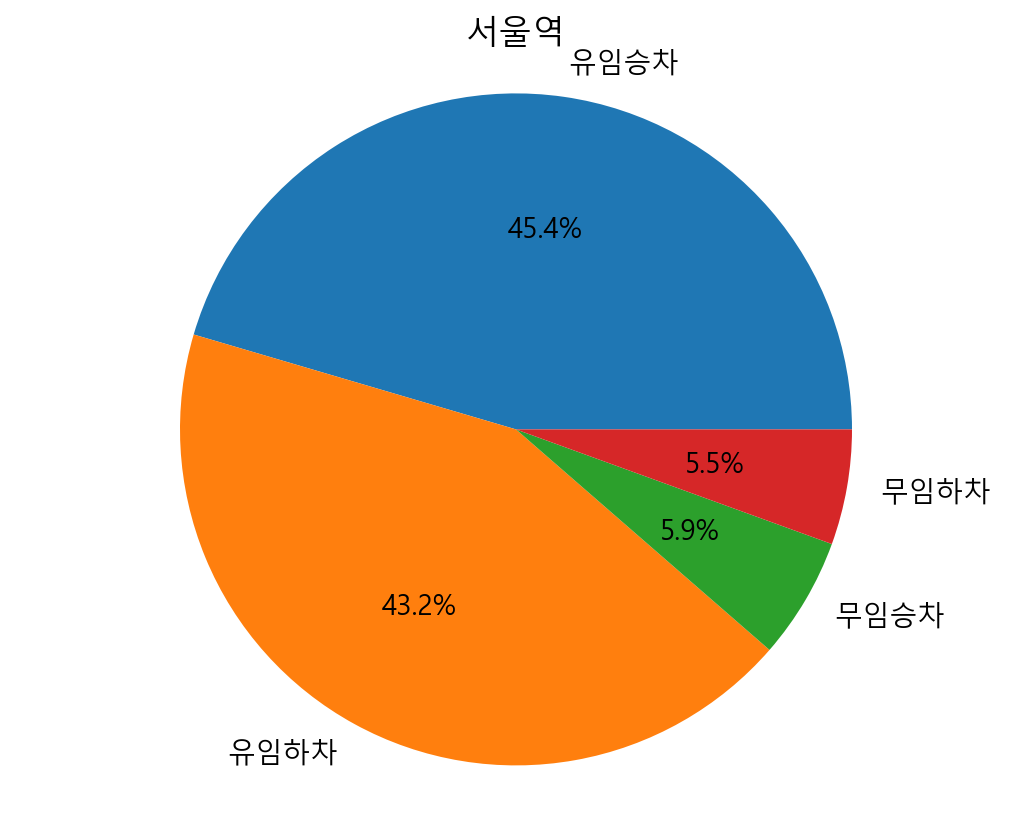

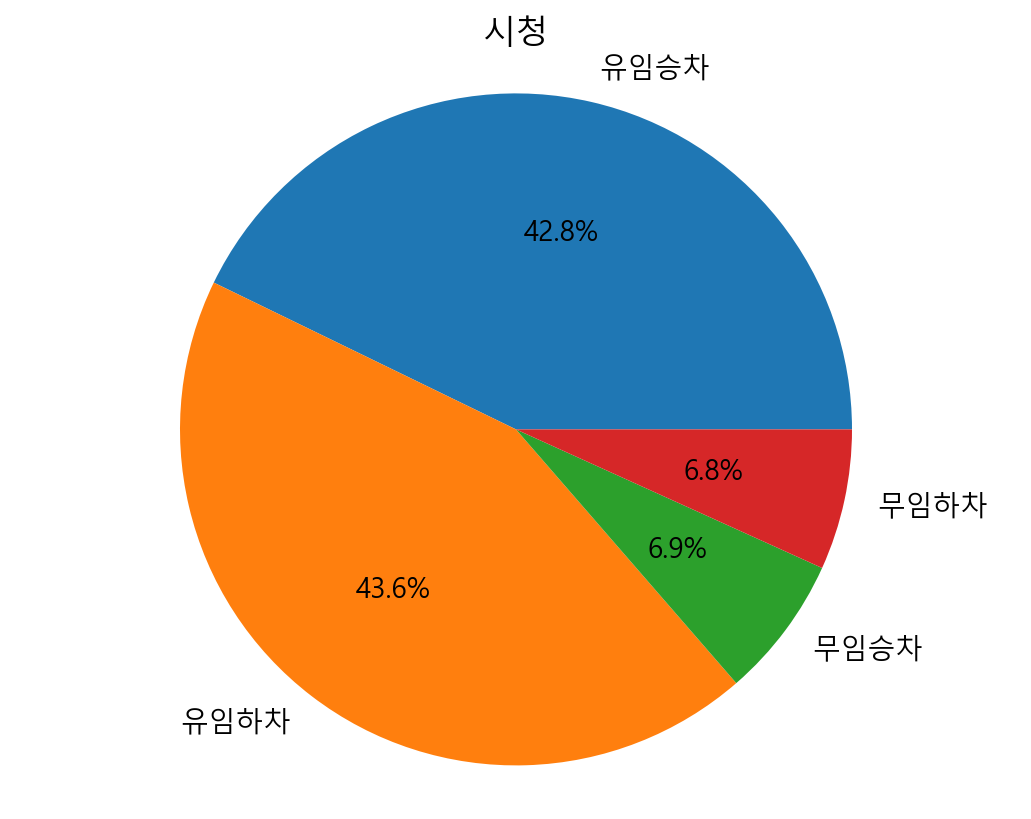

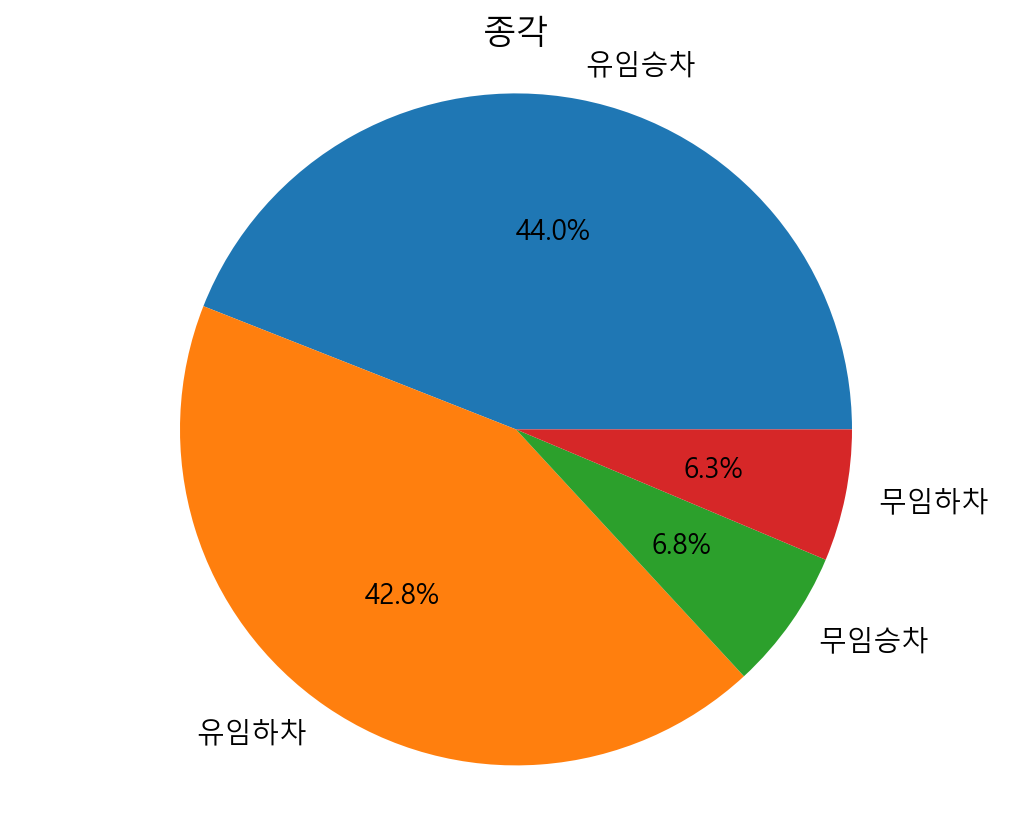

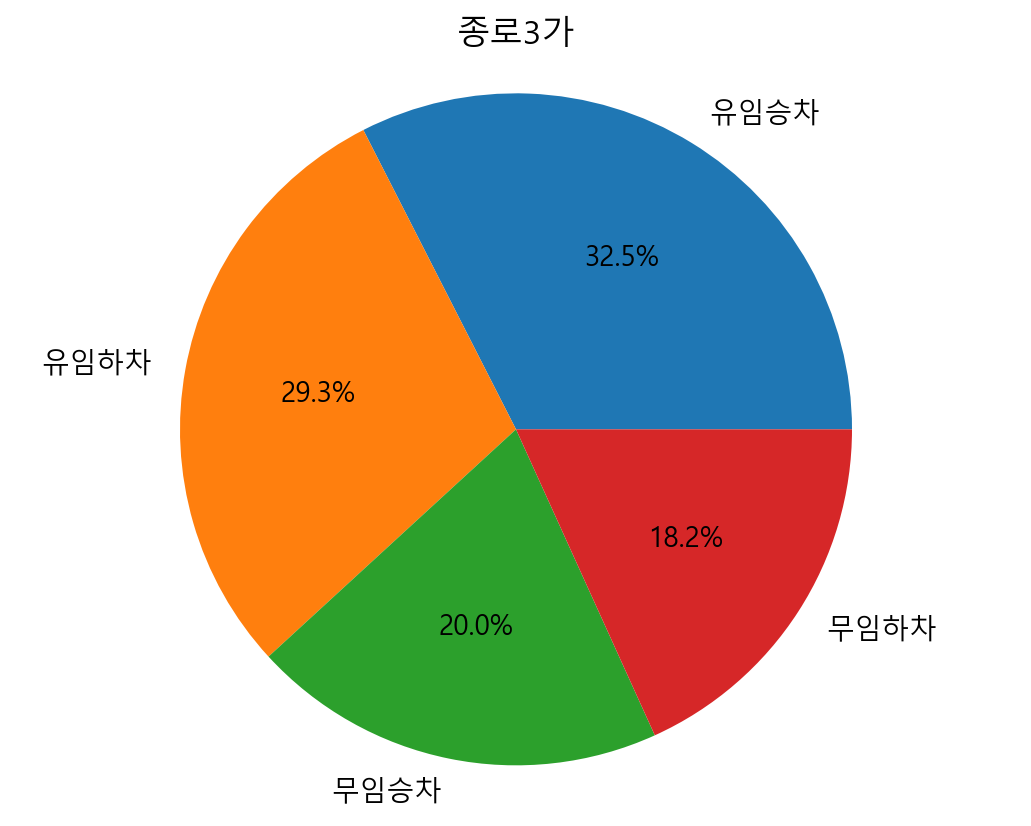

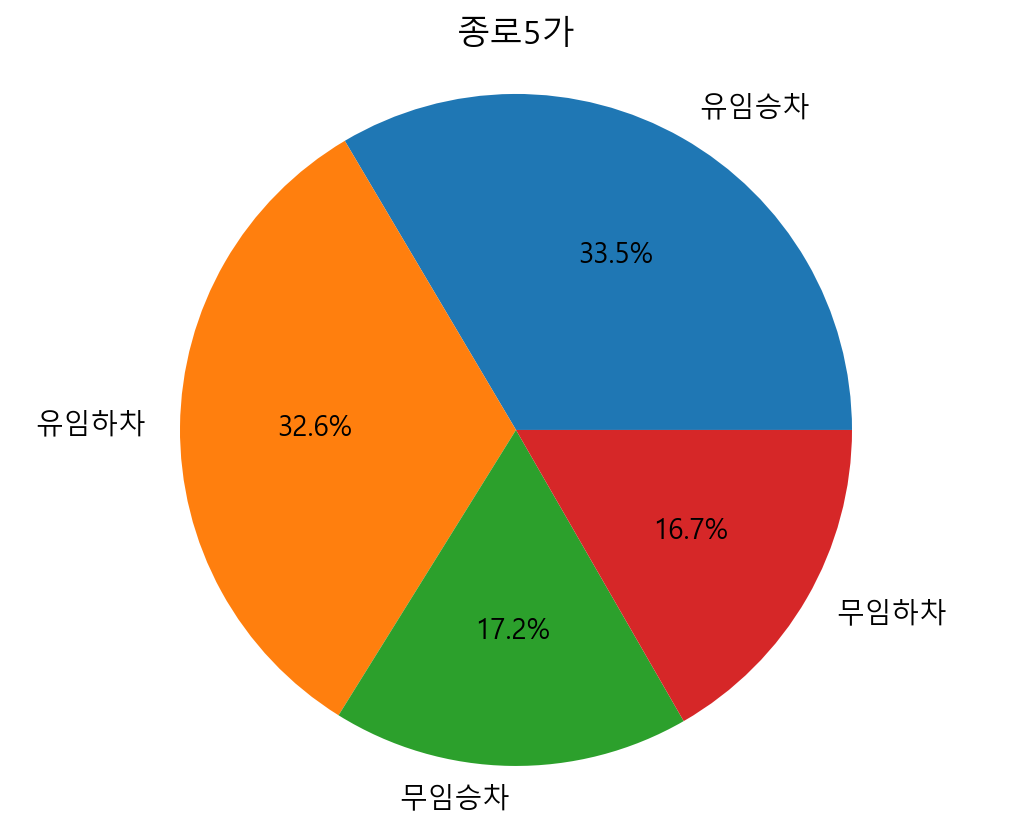

In [17]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')   # ✅ 'MalumGothic' → 'Malgun Gothic'
plt.rc('axes', unicode_minus=False) 

label = ['유임승차', '유임하차', '무임승차', '무임하차']

for idx, row in subwayfee_df.head().iterrows() :
    plt.figure(dpi = 200)
    plt.title(row['지하철역'])
    plt.pie(row[label], labels = label, autopct = '%.1f%%')
    plt.axis('equal')

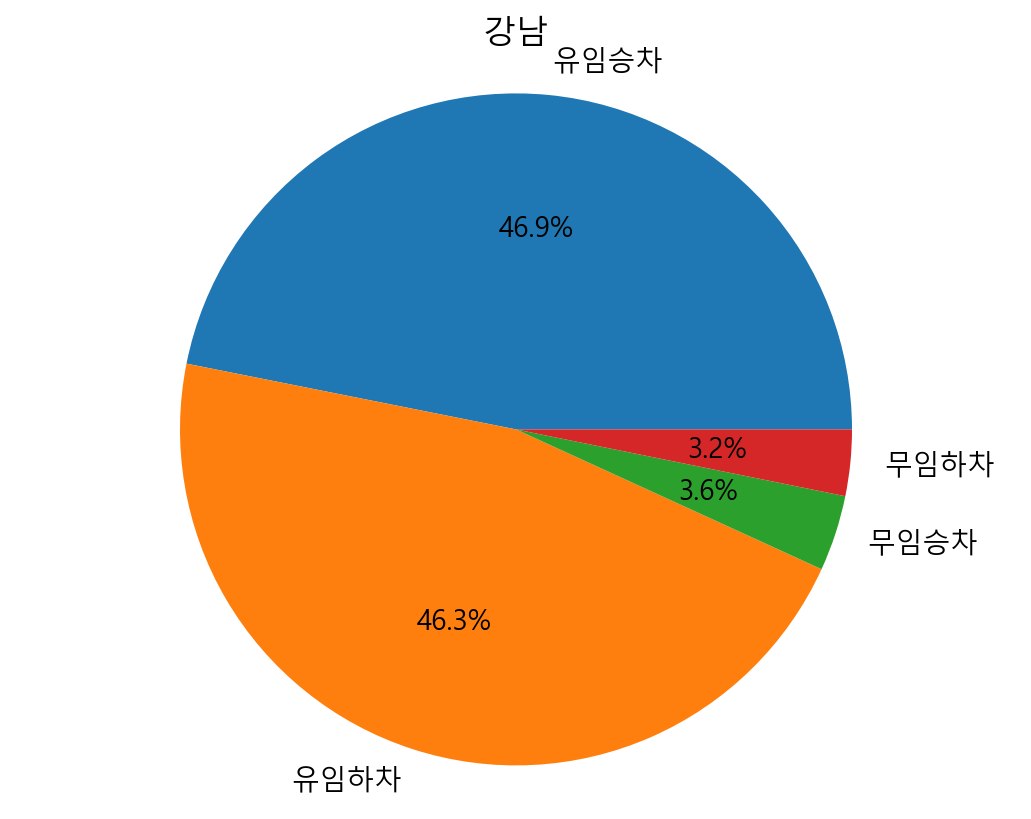

In [20]:
subway_name = input("지하철역 이름을 적어주세요 : ")

subway_data = subwayfee_df[subwayfee_df['지하철역'] == subway_name]

plt.figure(dpi=200)
plt.title(subway_name)
plt.pie(subway_data[label].values[0], labels=label, autopct='%.1f%%')
plt.axis('equal')
plt.savefig(f'{subway_name}.png')

In [22]:
import pandas as pd

subwaytime_df = pd.read_csv('3.3.3.subwaytime.csv')

subwaytime_df.head()

,사용월,호선명,역ID,지하철역,04:00:00~04:59:59,Unnamed: 5,05:00:00~05:59:59,Unnamed: 7,06:00:00~06:59:59,Unnamed: 9,...,23:00:00~23:59:59,Unnamed: 43,00:00:00~00:59:59,Unnamed: 45,01:00:00~01:59:59,Unnamed: 47,02:00:00~02:59:59,Unnamed: 49,03:00:00~03:59:59,Unnamed: 51
0,NaN,NaN,NaN,NaN,승차,하차,승차,하차,승차,하차,...,승차,하차,승차,하차,승차,하차,승차,하차,승차,하차
1,2025-02,1호선,150.0,서울역,587,54,8095,7283,22011,47821,...,30226,23594,3738,6137,10,165,0,1,0,0
2,2025-02,1호선,151.0,시청,118,0,1599,4243,3071,22889,...,8776,3061,516,755,0,9,0,0,0,0
3,2025-02,1호선,152.0,종각,122,2,3547,5593,3485,31295,...,24288,3918,1779,1047,0,0,0,0,0,0
4,2025-02,1호선,153.0,종로3가,108,7,2804,2329,3115,10133,...,13929,3711,1355,1641,0,14,0,0,0,0


In [23]:
subwaytime_df = subwaytime_df.drop(index = 0)

subwaytime_df.head()

,사용월,호선명,역ID,지하철역,04:00:00~04:59:59,Unnamed: 5,05:00:00~05:59:59,Unnamed: 7,06:00:00~06:59:59,Unnamed: 9,...,23:00:00~23:59:59,Unnamed: 43,00:00:00~00:59:59,Unnamed: 45,01:00:00~01:59:59,Unnamed: 47,02:00:00~02:59:59,Unnamed: 49,03:00:00~03:59:59,Unnamed: 51
1,2025-02,1호선,150.0,서울역,587,54,8095,7283,22011,47821,...,30226,23594,3738,6137,10,165,0,1,0,0
2,2025-02,1호선,151.0,시청,118,0,1599,4243,3071,22889,...,8776,3061,516,755,0,9,0,0,0,0
3,2025-02,1호선,152.0,종각,122,2,3547,5593,3485,31295,...,24288,3918,1779,1047,0,0,0,0,0,0
4,2025-02,1호선,153.0,종로3가,108,7,2804,2329,3115,10133,...,13929,3711,1355,1641,0,14,0,0,0,0
5,2025-02,1호선,154.0,종로5가,28,1,1654,3172,2557,13681,...,5306,3073,310,769,0,1,0,0,0,0


In [24]:
subwaytime_df = subwaytime_df.iloc[:, 4:].reset_index(drop = True)

subwaytime_df.head()

,04:00:00~04:59:59,Unnamed: 5,05:00:00~05:59:59,Unnamed: 7,06:00:00~06:59:59,Unnamed: 9,07:00:00~07:59:59,Unnamed: 11,08:00:00~08:59:59,Unnamed: 13,...,23:00:00~23:59:59,Unnamed: 43,00:00:00~00:59:59,Unnamed: 45,01:00:00~01:59:59,Unnamed: 47,02:00:00~02:59:59,Unnamed: 49,03:00:00~03:59:59,Unnamed: 51
0,587,54,8095,7283,22011,47821,71085,111528,119083,233868,...,30226,23594,3738,6137,10,165,0,1,0,0
1,118,0,1599,4243,3071,22889,6368,68186,9051,191547,...,8776,3061,516,755,0,9,0,0,0,0
2,122,2,3547,5593,3485,31295,5577,109649,9018,263977,...,24288,3918,1779,1047,0,0,0,0,0,0
3,108,7,2804,2329,3115,10133,4404,23736,7467,61192,...,13929,3711,1355,1641,0,14,0,0,0,0
4,28,1,1654,3172,2557,13681,4805,37192,8800,86179,...,5306,3073,310,769,0,1,0,0,0,0


<BarContainer object of 621 artists>

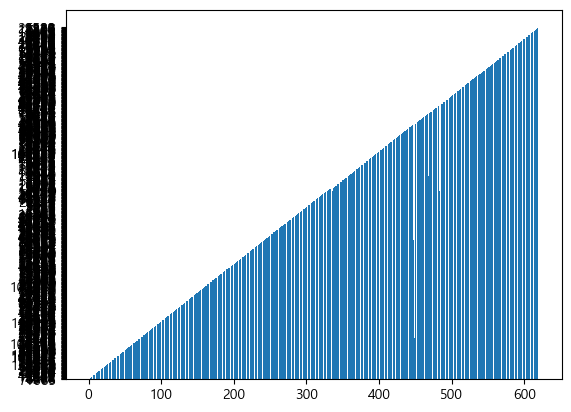

In [25]:
result = subwaytime_df['07:00:00~07:59:59'].tolist()

import matplotlib.pyplot as plt

plt.bar(range(len(result)), result)

In [26]:
subwaytime_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 621 entries, 0 to 620
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   04:00:00~04:59:59  621 non-null    str  
 1   Unnamed: 5         621 non-null    str  
 2   05:00:00~05:59:59  621 non-null    str  
 3   Unnamed: 7         621 non-null    str  
 4   06:00:00~06:59:59  621 non-null    str  
 5   Unnamed: 9         621 non-null    str  
 6   07:00:00~07:59:59  621 non-null    str  
 7   Unnamed: 11        621 non-null    str  
 8   08:00:00~08:59:59  621 non-null    str  
 9   Unnamed: 13        621 non-null    str  
 10  09:00:00~09:59:59  621 non-null    str  
 11  Unnamed: 15        621 non-null    str  
 12  10:00:00~10:59:59  621 non-null    str  
 13  Unnamed: 17        621 non-null    str  
 14  11:00:00~11:59:59  621 non-null    str  
 15  Unnamed: 19        621 non-null    str  
 16  12:00:00~12:59:59  621 non-null    str  
 17  Unnamed: 21        621 non-

<BarContainer object of 621 artists>

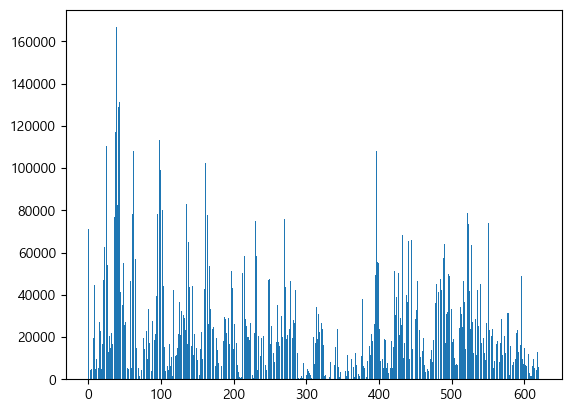

In [27]:
result = subwaytime_df['07:00:00~07:59:59'].astype('int64').tolist()

plt.bar(range(len(result)), result)

<BarContainer object of 621 artists>

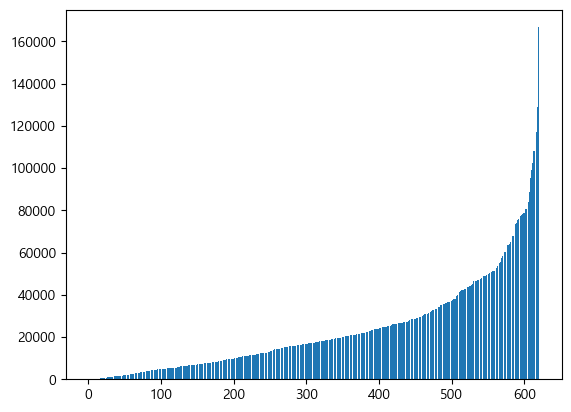

In [29]:
result.sort()

plt.bar(range(len(result)), result)

In [32]:
result_extended = subwaytime_df[['07:00:00~07:59:59', '08:00:00~08:59:59', '09:00:00~09:59:59']].astype('int64')

result_extended.head()

,07:00:00~07:59:59,08:00:00~08:59:59,09:00:00~09:59:59
0,71085,119083,94584
1,6368,9051,10999
2,5577,9018,11609
3,4404,7467,11241
4,4805,8800,11855


In [33]:
result_extended['합계'] = result_extended.sum(axis = 1)

result_extended.head()

,07:00:00~07:59:59,08:00:00~08:59:59,09:00:00~09:59:59,합계
0,71085,119083,94584,284752
1,6368,9051,10999,26418
2,5577,9018,11609,26204
3,4404,7467,11241,23112
4,4805,8800,11855,25460


<BarContainer object of 621 artists>

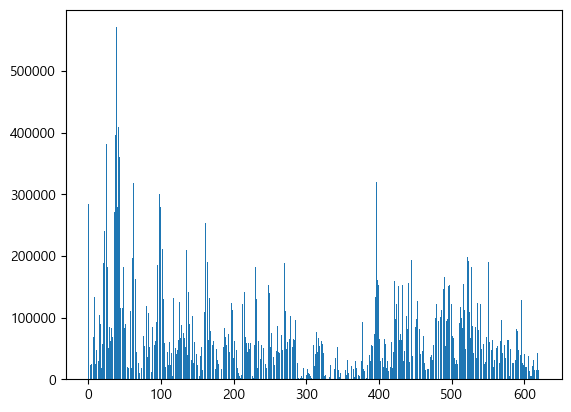

In [34]:
plt.bar(range(len(result_extended)), result_extended['합계'])

<BarContainer object of 621 artists>

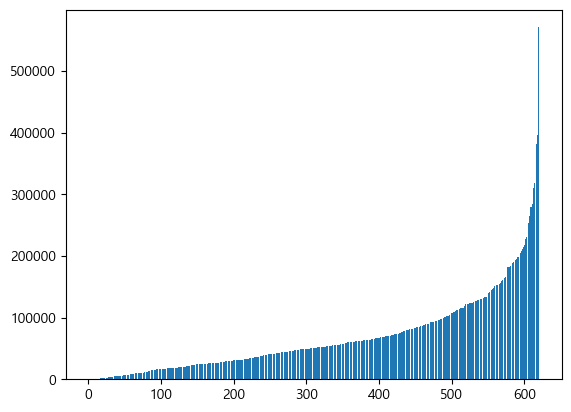

In [35]:
plt.bar(range(len(result_extended)), result_extended['합계'].sort_values())

In [37]:
result_extended['합계'].argmax()

np.int64(39)

In [38]:
subwaytime_df = pd.read_csv('3.3.3.subwaytime.csv')

subwaytime_df = subwaytime_df.drop(index = 0)

subwaytime_df.iloc[result_extended['합계'].argmax()][['호선명', '지하철역', '07:00:00~07:59:59', '08:00:00~08:59:59', '09:00:00~09:59:59']]

호선명                     2호선
지하철역                     신림
07:00:00~07:59:59    166687
08:00:00~08:59:59    252658
09:00:00~09:59:59    151624
Name: 40, dtype: object